In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class System():

    def __init__(self, Npoints=301, k=1, kT=1/3, xmin=-1, xmax=3, x=0, x0=0, x1=1, x2=2, sigma=0.1, n_samples=100000):
        self.k = k
        self.kT = kT
        self.xmin = xmin
        self.xmax = xmax
        self.n_samples = n_samples
        self.Npoints = Npoints

        self.x = x
        self.x0 = x0
        self.x1 = x1
        self.x2 = x2
        self.sigma = sigma

        self.energy = self.get_V(self.x)
        self.counts, self.bin_edges = self.run_Metropolis_Monte_Carlo()
        self.bin_centers = 0.5 * (self.bin_edges[:-1] + self.bin_edges[1:])
        
        self.xspace = np.linspace(self.xmin,self.xmax,self.Npoints)
        self.energies = self.get_V(self.xspace)

        self.p_exact = np.exp(-self.energies / self.kT)
        self.p_exact /= np.trapezoid(self.p_exact, self.xspace)   # divide by true area

    def integrate_p(self, a, b):
        mask = (a<=self.xspace) & (self.xspace<=b)  # pick xs from xspace between a and b
        return np.trapezoid(self.p_exact[mask], self.xspace[mask]) # get the area between a and b

    def get_V(self, x):
        return self.V0(x) + self.deltaV(x)

    def V0(self, x):
        return 5 + 1/2 * self.k * (x-self.x1)**2

    def deltaV(self, x):
        return - self.V0(self.x0)*np.exp(-(x-self.x0)**2/self.sigma**2) \
               - (self.V0(self.x1)+np.log(2))*np.exp(-(x-self.x1)**2/self.sigma**2) \
               - self.V0(self.x2)*np.exp(-(x-self.x2)**2/self.sigma**2)

    def proposed_x(self):
        p_x = np.random.rand() * abs(self.xmax - self.xmin) + self.xmin
        return p_x
    
    def step(self):
        proposed_x = self.proposed_x()
        proposed_energy = self.get_V(proposed_x)
        delta_E = proposed_energy - self.energy
        acceptance_probability = min(1, np.exp(-delta_E / self.kT))  # using P(x')/P(x) = exp(-E'/kT)/exp(E/kT) = exp(-delta_E/kT)
        # a clever way to choose randomly given a probability
        # if acceptance_probability=0.4, it is chosen 40% of times.
        if np.random.rand() < acceptance_probability:
            self.x = proposed_x
            self.energy = proposed_energy
    
    def run_Metropolis_Monte_Carlo(self):
        self.visited_states = []
        for _ in range(self.n_samples):
            self.step()
            self.visited_states.append(self.x)
        bin_shift = abs(self.xmax - self.xmin)/self.Npoints/2  # to ensure bins are centered around 0, 1, 2.
        counts, bin_edges = np.histogram(self.visited_states, bins=self.Npoints, range=(self.xmin-bin_shift, self.xmax+bin_shift))
        probabilites = counts/np.sum(counts)  # get mmc probabilites
        return probabilites, bin_edges  

    def thermal_avg(self):
        return np.mean([self.get_V(x) for x in self.visited_states])

    def plot(self, ax):
        bin_width = self.bin_edges[1] - self.bin_edges[0]
        P = self.counts/bin_width
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='C0', alpha =0.25)
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='None', edgecolor ='k')
        ax.set_title(r'$N_{samples}=$'+f'{self.n_samples}'+', 'r'$\langle V\rangle=$'+f'{self.thermal_avg():.3f}')
        ax.text(0.2, 1, r'$p=$'+f'{self.integrate_p(self.xmin, 1/2*(self.x0+self.x1)):.3g}', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
        ax.text(1.2, 1, r'$p=$'+f'{self.integrate_p(1/2*(self.x0+self.x1), 1/2*(self.x1+self.x2)):.3g}', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
        ax.text(2.2, 1, r'$p=$'+f'{self.integrate_p(1/2*(self.x1+self.x2), self.xmax):.3g}', ha='center', va='center',
                bbox=dict(boxstyle='round,pad=0.3',facecolor='white',alpha=0.5,edgecolor='none'))
        ax.plot(self.xspace, self.p_exact, 'k')
        ax.plot(self.xspace, self.get_V(self.xspace), 'k')


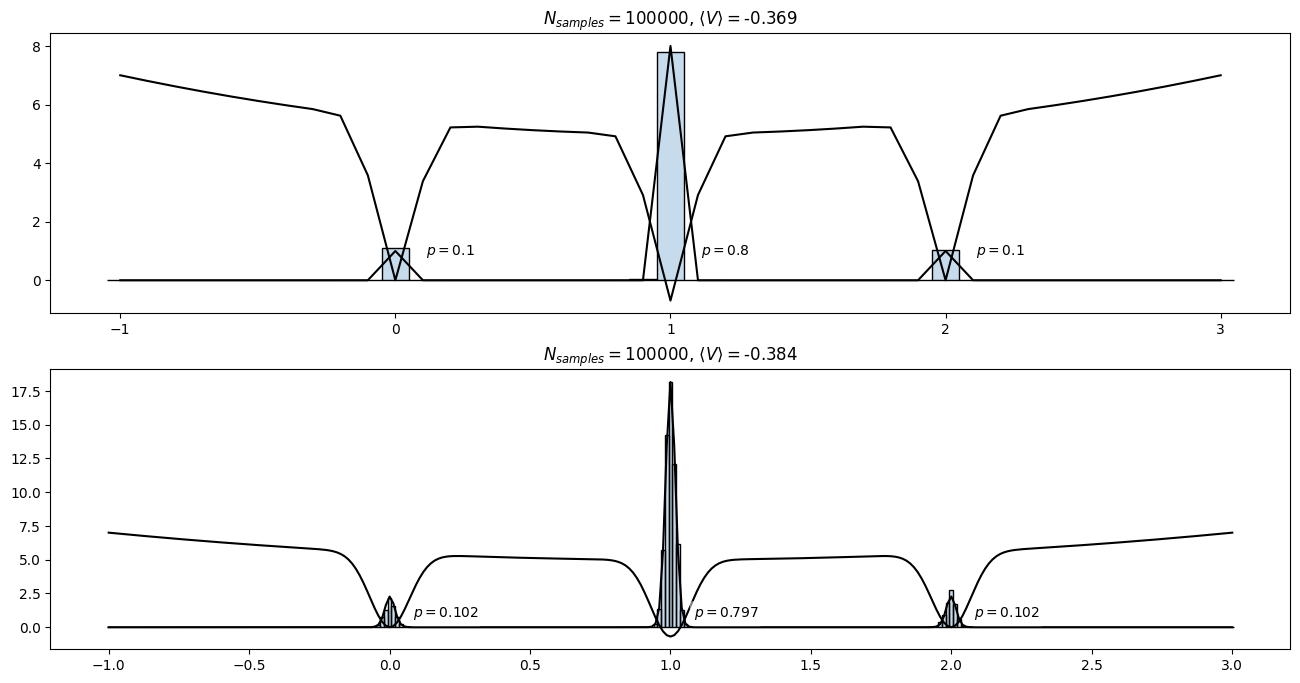

In [4]:
s41 = System(41)
s301 = System(301)

fig, axes = plt.subplots(2,1,figsize=(16,8))
s41.plot(axes[0])
s301.plot(axes[1])

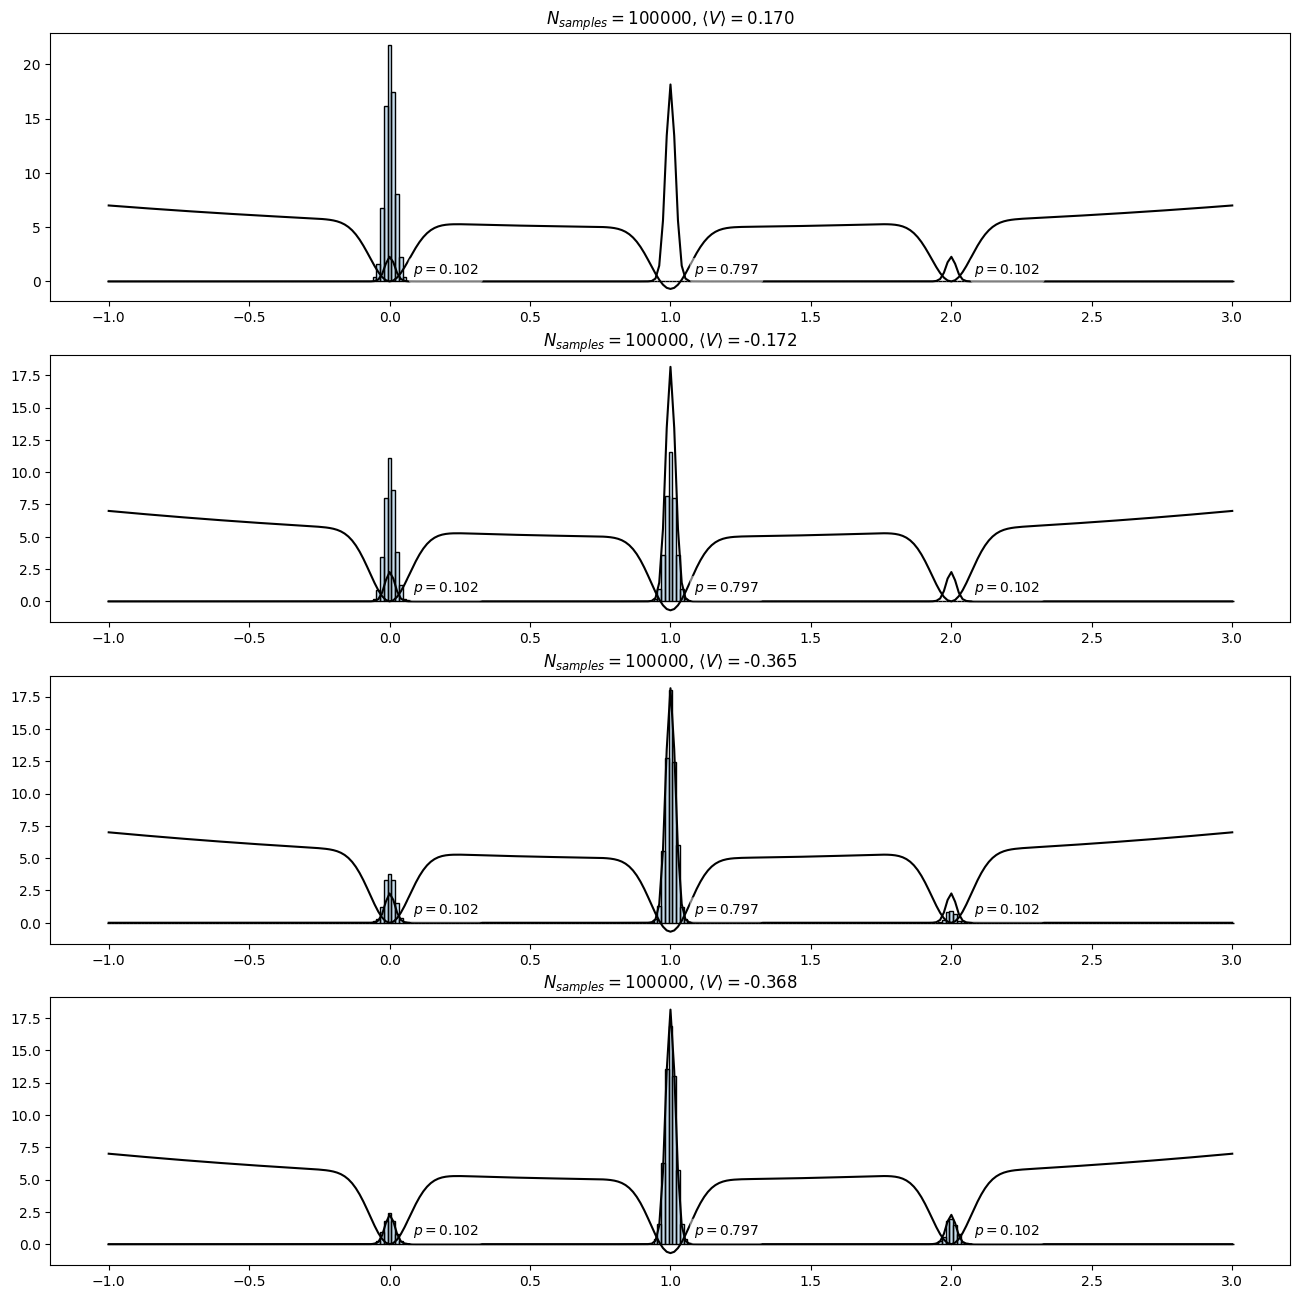

In [22]:
class SystemLocalProposal(System):
    def __init__(self, *args, delta=0.1, px0=0, **kwargs):
        self.delta = delta
        self.px0 = px0
        super().__init__(*args, **kwargs)

    def proposed_x(self):    
        p_x = self.x + np.random.normal(self.px0, self.delta)
        return p_x


deltas = [0.2, 0.25, 0.3, 0.35]

fig, axes = plt.subplots(4,1,figsize=(16,16))

for d, ax in zip(deltas, axes):
    sl = SystemLocalProposal(delta=d)
    sl.plot(ax)

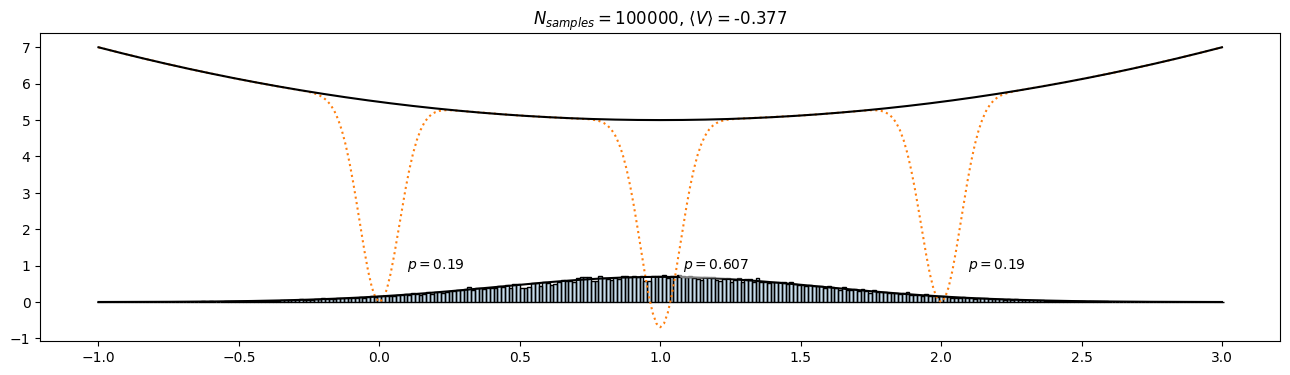

In [30]:
class SystemV0(System):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def get_V(self, x):
        return self.V0(x)

    def thermal_avg(self):
        # The numerator integral of  int{V(x)*exp(-deltaV(x)/kT)*P_0(x)}
        #                            = int{V(x)*exp(-deltaV(x)/kT)*1/Z_0*exp(-V_0(x)/kT)}
        #                            = 1/Z_0 *  int{V(x)*exp(-(V_0(x)+deltaV(x))/kT)}
        # The denominator integral   1/Z_0 * int{exp(-(V_0(x)+deltaV(x))/kT}
        # the 1/Z_0 will vanish, and we can compute like:

        V = self.V0(self.xspace)+self.deltaV(self.xspace)
        boltzmann = np.exp(-V/self.kT)

        num = np.trapezoid(V*boltzmann, self.xspace)  # numerator integral
        denom = np.trapezoid(boltzmann, self.xspace)  # denominator integral
        return num/denom

    def plot(self, ax):
        ax.plot(self.xspace, self.V0(self.xspace)+self.deltaV(self.xspace), color='C1', ls=':')
        super().plot(ax)

sV0 = SystemV0()
fig, ax = plt.subplots(1,1,figsize=(16,4))
sV0.plot(ax)
    

We get the same thermal average $\langle V\rangle$ as before